In [1]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.feature as cfeature

import easygems.healpix as egh
import healpy as hp

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob

## Functions

In [2]:
import matplotlib.colors as mcolors
def plot_map_healpix(da, ax=None, title=None, colorbar=True, cmap="viridis", nest=True, vmin=None, vmax=None, space=None, extend=None, label=None, latmin=-90, latmax=90, lonmin=-180, lonmax=180):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    
    if not ax:
        projection = ccrs.PlateCarree(central_longitude=225)
        fig, ax = plt.subplots(
            subplot_kw={"projection": projection}, constrained_layout=True, figsize=(15, 10)
        )
    ax.set_extent([lonmin, lonmax, latmin, latmax], ccrs.PlateCarree())
    ax.coastlines()
    ax.set_title(title)
    
    # Use the range values if provided
    norm = None
    if vmin is not None and vmax is not None:
        norm = plt.Normalize(vmin, vmax)
        norm = mcolors.BoundaryNorm(np.linspace(vmin, vmax, space), cmap.N, extend=extend)

    pc = egh.healpix_show(da, ax=ax, cmap=cmap, norm=norm, nest=nest)
    
    if colorbar:
        #cbar = fig.colorbar(pc, ax=ax, orientation="horizontal", pad=0.05)
        bounds = np.linspace(vmin,vmax,space)
        pc.set_clim(vmin, vmax)
        cb = plt.colorbar(pc, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend,ticks=bounds, boundaries=bounds)
        cb.ax.set_facecolor('none')
        cb.set_label(label=label, size=15, weight='bold')
        cb.ax.tick_params(labelsize=20)
        cb.ax.set_xticklabels(bounds,rotation=270)
       # if levels is not None:
       #      cbar.set_ticks(levels)
    kw = {'levels':[-1], 'colors':['red'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                      ax=ax,
                      transform=ccrs.PlateCarree(),
                      **kw
                     )
    
    _ = fig.subplots_adjust(left=0.01, right=0.98, hspace=0, wspace=0, top=0.9, bottom=0.25)
    return pc

In [3]:
def plot_monthly_maps(da, cmap="viridis", nest=True, vmin=None, vmax=None, space=None, extend=None, label=None,
                      latmin=-90, latmax=90, lonmin=-180, lonmax=180):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES

    fig, axes = plt.subplots(3, 4, figsize=(20, 25), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=225)})

    for i, ax in enumerate(axes.flat):
        month_data = da.sel(month = (i + 1))  # Select and average each month

        ax.set_extent([lonmin, lonmax, latmin, latmax], ccrs.PlateCarree())
        ax.coastlines()
        ax.set_title(f"Month {i+1}", fontsize=15, weight='bold')

        # Normalize color scale
        norm = plt.Normalize(vmin, vmax) if vmin is not None and vmax is not None else None

        # Plot data
        pc = egh.healpix_show(month_data, ax=ax, cmap=cmap, norm=norm, nest=nest)

        # Add Amazon biome contour
        kw = {'levels': [-1], 'colors': ['red'], 'linestyles': ['solid']}
        AMZ_BD.plot.contour(ax=ax, transform=ccrs.PlateCarree(), **kw)

    # Add colorbar
    cb_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])  # Colorbar position
    bounds = np.linspace(vmin, vmax, space) if space else None
    cb = plt.colorbar(pc, cax=cb_ax, orientation="horizontal", extend=extend, ticks=bounds, boundaries=bounds)
    cb.set_label(label=label, size=20, weight='bold')
    cb.ax.tick_params(labelsize=15)

    plt.tight_layout()
    plt.show()


In [4]:
def get_amazon_index(nside=12**2, nest=True):
    amazon = xr.open_dataset(
        "/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc"
    ).stack(cell=("latitude", "longitude"))
    
    is_amazon = amazon.where(amazon.AMAZON_BIOMES == 0, drop=True)
    
    return np.unique(hp.ang2pix(nside, is_amazon.longitude.values, is_amazon.latitude.values, nest=nest, lonlat=True)).astype(int)


In [5]:
# IFS
def samerica(ds):
     return (ds.lat >= -60) & (ds.lat <= 20) & (ds.lon >= 260) & (ds.lon <= 340)
def amazon(ds):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    AMZ_BD['longitude'] = (AMZ_BD['longitude'] + 360) % 360 # change from -180-180 to 0-360
    grid_amz = AMZ_BD.interp(latitude=ds.lat, longitude=ds.lon)
    return (ds.lat >= -30) & (ds.lat <= 20) & (ds.lon >= 270) & (ds.lon <= 330) & (grid_amz==0)

In [6]:
def colormap_create(cmap, cnumber, loc_boundary_low, loc_boundary_high):
    get_cmap = cm.get_cmap(cmap,cnumber) 
    cmap_edit = get_cmap(np.linspace(0,1,cnumber))
    white = np.array([255/256, 255/256, 255/256, 1])
    cmap_edit[loc_boundary_low:loc_boundary_high] = white
    cmap_new = matplotlib.colors.ListedColormap(cmap_edit)
    return cmap_new

In [7]:
BrBG_new = colormap_create('BrBG',21,9,12)
RdBu_new = colormap_create('RdBu_r',21,9,12)

/tmp/ipykernel_242531/511728102.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  get_cmap = cm.get_cmap(cmap,cnumber)


## Load datasets - P4K, 4CO2, NGC

In [8]:
# ICON CTL (5km)
import intake
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
data_ctl  = cat['ICON.C5.AMIP_CNTL'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1997 (19 years)

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [9]:
dx_p4k  = cat['ICON.C5.AMIP_P4K'](time="P1D", zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1993 (15 years)

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [10]:
dx_4co2 = cat['ICON.C5.AMIP_4CO2'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1980-1994 (15 years)

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [11]:
# NGC4
dx_ngc = cat.ICON.ngc4008(zoom=9).to_dask().pipe(egh.attach_coords)

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [12]:
dx_ngc_start = dx_ngc.sel(time=slice('2024-01-01', '2028-12-31')) # 5 years
dx_ngc_end = dx_ngc.sel(time=slice('2045-01-01', '2049-12-31')) # 5years

In [ ]:
# Cathy
lw_dir = '/scratch/m/m300948/AMIP_cathy/lw'

rlut_amip = xr.open_mfdataset(lw_dir + '/amip_rlut.nc',parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['rlut']
rlds_amip = xr.open_mfdataset(lw_dir + '/amip_rlds.nc',parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['rlds']
rlus_amip = xr.open_mfdataset(lw_dir + '/amip_rlus.nc',parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['rlus']

In [19]:
sw_dir = '/scratch/m/m300948/AMIP_cathy/sw'

rsds_amip = xr.open_mfdataset(sw_dir + '/amip_rsds.nc',parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['rsds']
rsus_amip = xr.open_mfdataset(sw_dir + '/amip_rsus.nc',parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['rsus']
rsdt_amip = xr.open_mfdataset(sw_dir + '/amip_rsdt.nc',parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['rsdt']
rsut_amip = xr.open_mfdataset(sw_dir + '/amip_rsut.nc',parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['rsut']

# Over the Amazon

## 1. Latent and sensible heat [W/m2]

### Amazon masking

In [13]:
is_amazon = get_amazon_index(nside=egh.get_nside(data_ctl))
dx_ctl_amz = data_ctl.isel(cell=is_amazon).sel(time=slice("1980", "1994")) 
dx_p4k_amz = dx_p4k.isel(cell=is_amazon).sel(time=slice("1979", "1993"))
dx_4co2_amz = dx_4co2.isel(cell=is_amazon).sel(time=slice("1980", "1994"))

In [14]:
# NGC4
is_amazon_ngc = get_amazon_index(nside=egh.get_nside(dx_ngc))
dx_ngc_start_amz = dx_ngc_start.isel(cell=is_amazon_ngc)
dx_ngc_end_amz = dx_ngc_end.isel(cell=is_amazon_ngc)

In [44]:
# Cathy's amip
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome_amip = AMZ_BD.interp(latitude=rlut_amip.lat, longitude=rlut_amip.lon)

rlut_amip_amz = rlut_amip.where(ABinterp_biome_amip == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
rlds_amip_amz = rlds_amip.where(ABinterp_biome_amip == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
rlus_amip_amz = rlus_amip.where(ABinterp_biome_amip == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [46]:
rsds_amip_amz = rsds_amip.where(ABinterp_biome_amip == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
rsus_amip_amz = rsus_amip.where(ABinterp_biome_amip == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
rsdt_amip_amz = rsdt_amip.where(ABinterp_biome_amip == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
rsut_amip_amz = rsut_amip.where(ABinterp_biome_amip == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

_AMIP_

In [15]:
hfls_ctl_amz_mon = -dx_ctl_amz.hfls.groupby('time.month').mean('time') 
hfls_p4k_amz_mon = -dx_p4k_amz.hfls.groupby('time.month').mean('time') 
hfls_4co2_amz_mon = -dx_4co2_amz.hfls.groupby('time.month').mean('time') 

In [16]:
hfss_ctl_amz_mon = -dx_ctl_amz.hfss.groupby('time.month').mean('time') 
hfss_p4k_amz_mon = -dx_p4k_amz.hfss.groupby('time.month').mean('time') 
hfss_4co2_amz_mon = -dx_4co2_amz.hfss.groupby('time.month').mean('time') 

In [21]:
print(hfss_ctl_amz_mon.mean(dim=('cell','month')).values)
print(hfss_4co2_amz_mon.mean(dim=('cell','month')).values)
print(hfss_p4k_amz_mon.mean(dim=('cell','month')).values)

30.234016
28.630177
34.40147


In [22]:
print(hfls_ctl_amz_mon.mean(dim=('cell','month')).values)
print(hfls_4co2_amz_mon.mean(dim=('cell','month')).values)
print(hfls_p4k_amz_mon.mean(dim=('cell','month')).values)

125.87743
128.53659
132.98305


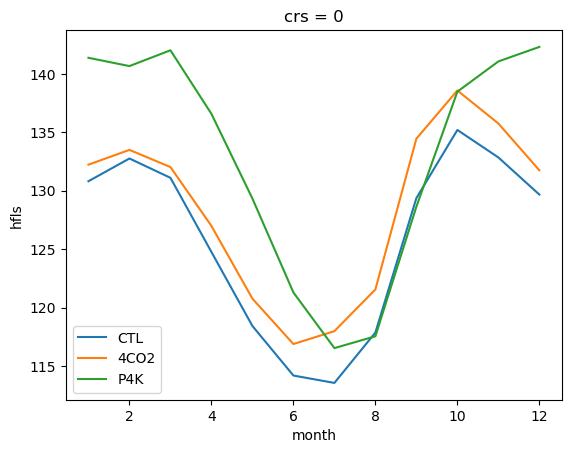

In [22]:
hfls_ctl_amz_mon.mean('cell').plot()
hfls_4co2_amz_mon.mean('cell').plot()
hfls_p4k_amz_mon.mean('cell').plot()
plt.legend(['CTL', '4CO2', 'P4K'])

_NGC ICON_

In [ ]:
hfls_ngc_start_month = -dx_ngc_start.hfls.groupby('time.month').mean('time') 
hfls_ngc_end_month = -dx_ngc_end.hfls.groupby('time.month').mean('time') 

In [ ]:
hfss_ngc_start_month = -dx_ngc_start.hfss.groupby('time.month').mean('time') 
hfss_ngc_end_month = -dx_ngc_end.hfss.groupby('time.month').mean('time') 

In [28]:
bw_ngc_start_amz_month = hfss_ngc_start_amz_month / hfls_ngc_start_amz_month
bw_ngc_end_amz_month = hfss_ngc_end_amz_month / hfls_ngc_end_amz_month

In [ ]:
print(hfls_ngc_start_month.mean(dim=('cell', 'month')).values)
print(hfls_ngc_end_month.mean(dim=('cell', 'month')).values)
print(hfss_ngc_start_month.mean(dim=('cell', 'month')).values)
print(hfss_ngc_end_month.mean(dim=('cell', 'month')).values)

104.59229
99.36968
48.56403
54.644928


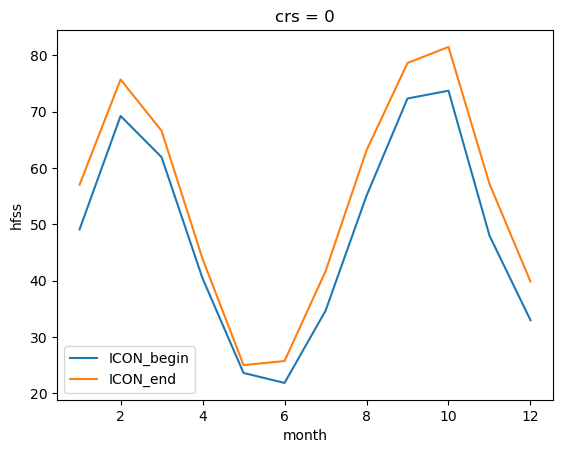

In [29]:
hfss_ngc_start_amz_month.mean('cell').plot()
hfss_ngc_end_amz_month.mean('cell').plot()
plt.legend(['ICON_begin', 'ICON_end'])

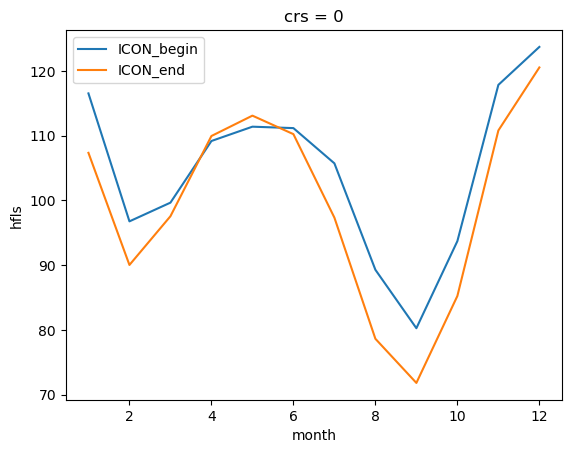

In [30]:
hfls_ngc_start_amz_month.mean('cell').plot()
hfls_ngc_end_amz_month.mean('cell').plot()
plt.legend(['ICON_begin', 'ICON_end'])

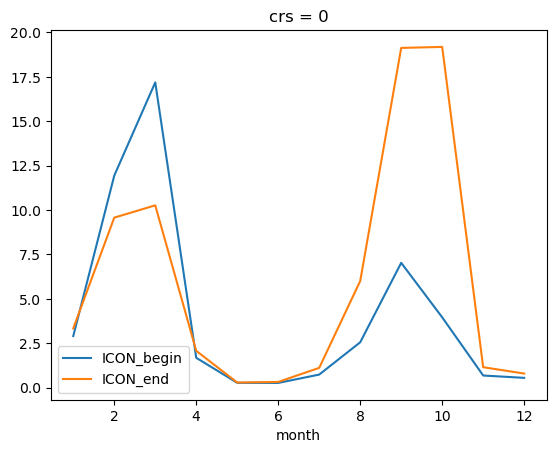

In [31]:
bw_ngc_start_amz_month.mean('cell').plot()
bw_ngc_end_amz_month.mean('cell').plot()
plt.legend(['ICON_begin', 'ICON_end'])

## Net surface radiation

_AMIP_

In [58]:
dx_p4k_amz.tas.sel(time=slice("1979", "1993")).mean('time').mean('cell').values

array(301.18948, dtype=float32)

In [20]:
# RLDS
rlds_ctl_amz_mon = dx_ctl_amz.rlds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rlds_p4k_amz_mon = dx_p4k_amz.rlds.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rlds_4co2_amz_mon = dx_4co2_amz.rlds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [21]:
# RLUS
rlus_ctl_amz_mon = dx_ctl_amz.rlus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rlus_p4k_amz_mon = dx_p4k_amz.rlus.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rlus_4co2_amz_mon = dx_4co2_amz.rlus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [22]:
# RSDS
rsds_ctl_amz_mon = dx_ctl_amz.rsds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rsds_p4k_amz_mon = dx_p4k_amz.rsds.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rsds_4co2_amz_mon = dx_4co2_amz.rsds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [23]:
# RSUS
rsus_ctl_amz_mon = dx_ctl_amz.rsus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rsus_p4k_amz_mon = dx_p4k_amz.rsus.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rsus_4co2_amz_mon = dx_4co2_amz.rsus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [19]:
print(rlds_ctl_amz_mon.mean(dim=('cell','month')).values)
print(rlds_4co2_amz_mon.mean(dim=('cell','month')).values)
print(rlds_p4k_amz_mon.mean(dim=('cell','month')).values)

print(rlus_ctl_amz_mon.mean(dim=('cell','month')).values)
print(rlus_4co2_amz_mon.mean(dim=('cell','month')).values)
print(rlus_p4k_amz_mon.mean(dim=('cell','month')).values)

print(rsds_ctl_amz_mon.mean(dim=('cell','month')).values)
print(rsds_4co2_amz_mon.mean(dim=('cell','month')).values)
print(rsds_p4k_amz_mon.mean(dim=('cell','month')).values)

print(rsus_ctl_amz_mon.mean(dim=('cell','month')).values)
print(rsus_4co2_amz_mon.mean(dim=('cell','month')).values)
print(rsus_p4k_amz_mon.mean(dim=('cell','month')).values)

394.3862
399.54245
429.33035
438.69446
441.1972
467.52332
234.92847
233.12419
241.05978
34.271435
34.0009
35.127758


In [23]:
sfc_Rd_ctl_amz_mon = rlds_ctl_amz_mon - rlus_ctl_amz_mon + rsds_ctl_amz_mon - rsus_ctl_amz_mon
sfc_Rd_p4k_amz_mon = rlds_p4k_amz_mon - rlus_p4k_amz_mon + rsds_p4k_amz_mon - rsus_p4k_amz_mon
sfc_Rd_4co2_amz_mon = rlds_4co2_amz_mon - rlus_4co2_amz_mon + rsds_4co2_amz_mon - rsus_4co2_amz_mon

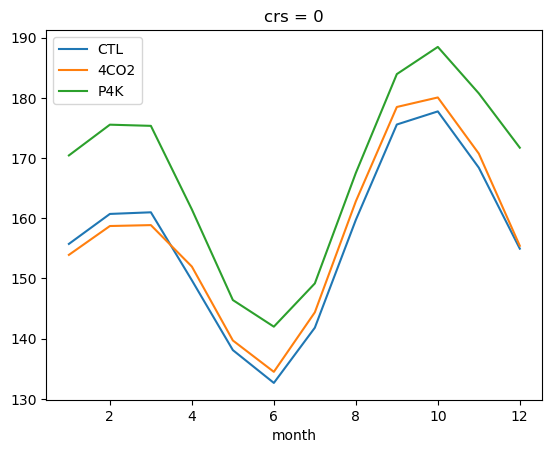

In [24]:
sfc_Rd_ctl_amz_mon.mean('cell').plot()
sfc_Rd_4co2_amz_mon.mean('cell').plot()
sfc_Rd_p4k_amz_mon.mean('cell').plot()
plt.legend(['CTL', '4CO2', 'P4K'])

In [25]:
print(sfc_Rd_ctl_amz_mon.mean('cell').values)
print(sfc_Rd_4co2_amz_mon.mean('cell').values) 
print(sfc_Rd_p4k_amz_mon.mean('cell').values)

[155.74428 160.72504 160.9956  149.7001  138.10388 132.65118 141.82558
 159.7376  175.58037 177.7585  168.4081  154.95451]
[153.92256 158.71709 158.8688  151.97792 139.70233 134.49327 144.37834
 162.82266 178.49232 180.07439 170.74615 155.4273 ]
[170.44421 175.55386 175.35797 161.47272 146.4196  141.99554 149.18228
 167.53667 183.95503 188.4705  180.75174 171.72815]


In [32]:
print(np.sum(np.array([155.74428, 160.72504, 160.9956,  149.7001, 138.10388, 132.65118, 141.82558,
159.7376,  175.58037, 177.7585, 168.4081, 154.95451])/12))
print(np.sum([153.92256, 158.71709, 158.8688,  151.97792, 139.70233, 134.49327, 144.37834,
162.82266, 178.49232, 180.07439, 170.74615, 155.4273 ])/12)
print(np.sum([170.44421, 175.55386, 175.35797, 161.47272, 146.4196, 141.99554, 149.18228,
167.53667, 183.95503, 188.4705, 180.75174, 171.72815])/12)

156.34872833333336
157.4685941666667
167.73902249999998


In [ ]:
plot_map_healpix(pr_ngce_wet*86400 - pr_ngcs_wet*86400, ax=None, title=None, colorbar=True, cmap=BrBG_new, nest=True, vmin=-1, vmax=1, space=5, extend='both', latmin=-60, latmax=20, lonmin=-100, lonmax=-20)

_Cathy: AMIP_

In [48]:
# LW
rlut_amip_amz_mon = rlut_amip_amz.groupby('time.month').mean('time') 
rlds_amip_amz_mon = rlds_amip_amz.groupby('time.month').mean('time') 
rlus_amip_amz_mon = rlus_amip_amz.groupby('time.month').mean('time') 

In [49]:
# SW
rsds_amip_amz_mon = rsds_amip_amz.groupby('time.month').mean('time') 
rsus_amip_amz_mon = rsus_amip_amz.groupby('time.month').mean('time') 
rsdt_amip_amz_mon = rsdt_amip_amz.groupby('time.month').mean('time') 
rsut_amip_amz_mon = rsut_amip_amz.groupby('time.month').mean('time') 

In [50]:
print(rlut_amip_amz_mon.mean(dim=('lat','lon','month')).values)
print(rlds_amip_amz_mon.mean(dim=('lat','lon','month')).values)
print(rlus_amip_amz_mon.mean(dim=('lat','lon','month')).values)

print(rsds_amip_amz_mon.mean(dim=('lat','lon','month')).values)
print(rsus_amip_amz_mon.mean(dim=('lat','lon','month')).values)
print(rsdt_amip_amz_mon.mean(dim=('lat','lon','month')).values)
print(rsut_amip_amz_mon.mean(dim=('lat','lon','month')).values)

239.9329
399.36136
439.25232
224.96323
32.862373
413.04587
123.47034


In [51]:
net_Rd_amip = rsus_amip_amz_mon - rsds_amip_amz_mon + rlus_amip_amz_mon - rlds_amip_amz_mon + rsdt_amip_amz_mon - rsut_amip_amz_mon - rlus_amip_amz_mon

In [53]:
net_Rd_amip.mean(dim=('lat','lon','month')).values

array(-301.88663, dtype=float32)

_ICON_

In [20]:
rlds_ngc_start_amz_month = dx_ngc_start_amz.rlds.groupby('time.month').mean('time') 
rlds_ngc_end_amz_month = dx_ngc_end_amz.rlds.groupby('time.month').mean('time') 

rlus_ngc_start_amz_month = dx_ngc_start_amz.rlus.groupby('time.month').mean('time') 
rlus_ngc_end_amz_month = dx_ngc_end_amz.rlus.groupby('time.month').mean('time') 

rsds_ngc_start_amz_month = dx_ngc_start_amz.rsds.groupby('time.month').mean('time') 
rsds_ngc_end_amz_month = dx_ngc_end_amz.rsds.groupby('time.month').mean('time') 

rsus_ngc_start_amz_month = dx_ngc_start_amz.rsus.groupby('time.month').mean('time') 
rsus_ngc_end_amz_month = dx_ngc_end_amz.rsus.groupby('time.month').mean('time') 

In [21]:
print(rlds_ngc_start_amz_month.mean(dim=('cell','month')).values)
print(rlds_ngc_end_amz_month.mean(dim=('cell','month')).values)

print(rlus_ngc_start_amz_month.mean(dim=('cell','month')).values)
print(rlus_ngc_end_amz_month.mean(dim=('cell','month')).values)

print(rsds_ngc_start_amz_month.mean(dim=('cell','month')).values)
print(rsds_ngc_end_amz_month.mean(dim=('cell','month')).values)

print(rsus_ngc_start_amz_month.mean(dim=('cell','month')).values)
print(rsus_ngc_end_amz_month.mean(dim=('cell','month')).values)

389.69437
393.8557
446.98575
453.76013
246.4951
250.5142
35.93585
36.518936


In [20]:
sfc_Rd_ngc_start_amz_mon = rlds_ngc_start_amz_month - rlus_ngc_start_amz_month + rsds_ngc_start_amz_month - rsus_ngc_start_amz_month
sfc_Rd_ngc_end_amz_mon = rlds_ngc_end_amz_month - rlus_ngc_end_amz_month + rsds_ngc_end_amz_month - rsus_ngc_end_amz_month

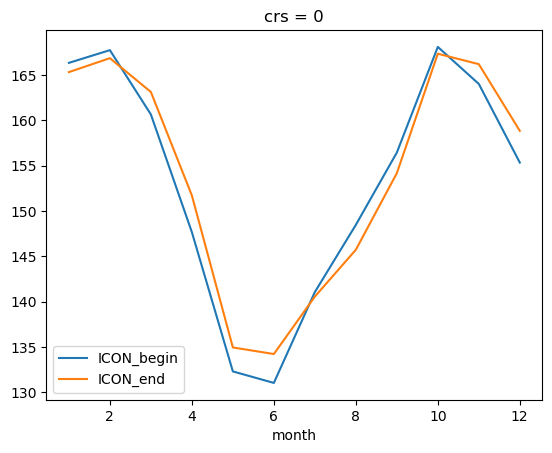

In [ ]:
sfc_Rd_ngc_start_amz_mon.mean('cell').plot()
sfc_Rd_ngc_end_amz_mon.mean('cell').plot()
plt.legend(['ICON_begin', 'ICON_end'])

## Plotting

In [18]:
hfls_ctl_mon = -data_ctl.hfls.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
hfls_p4k_mon = -dx_p4k.hfls.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
hfls_4co2_mon = -dx_4co2.hfls.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [19]:
hfss_ctl_mon = -data_ctl.hfss.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
hfss_p4k_mon = -dx_p4k.hfss.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
hfss_4co2_mon = -dx_4co2.hfss.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [20]:
rlds_ctl_mon = data_ctl.rlds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rlds_p4k_mon = dx_p4k.rlds.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rlds_4co2_mon = dx_4co2.rlds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [21]:
rlus_ctl_mon = data_ctl.rlus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rlus_p4k_mon = dx_p4k.rlus.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rlus_4co2_mon = dx_4co2.rlus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [22]:
rsds_ctl_mon = data_ctl.rsds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rsds_p4k_mon = dx_p4k.rsds.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rsds_4co2_mon = dx_4co2.rsds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [23]:
rsus_ctl_mon = data_ctl.rsus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rsus_p4k_mon = dx_p4k.rsus.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rsus_4co2_mon = dx_4co2.rsus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [24]:
rsdt_ctl_mon = data_ctl.rsdt.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rsdt_p4k_mon = dx_p4k.rsdt.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rsdt_4co2_mon = dx_4co2.rsdt.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [25]:
rsut_ctl_mon = data_ctl.rsut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rsut_p4k_mon = dx_p4k.rsut.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rsut_4co2_mon = dx_4co2.rsut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [26]:
rlut_ctl_mon = data_ctl.rlut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rlut_p4k_mon = dx_p4k.rlut.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rlut_4co2_mon = dx_4co2.rlut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [27]:
Rd_ctl_mon = rlds_ctl_mon - rlus_ctl_mon + rsds_ctl_mon - rsus_ctl_mon
Rd_p4k_mon = rlds_p4k_mon - rlus_p4k_mon + rsds_p4k_mon - rsus_p4k_mon
Rd_4co2_mon = rlds_4co2_mon - rlus_4co2_mon + rsds_4co2_mon - rsus_4co2_mon

_ngc_

In [ ]:
hfls_ngc_start_month = -dx_ngc_start.hfls.groupby('time.month').mean('time') 
hfls_ngc_end_month = -dx_ngc_end.hfls.groupby('time.month').mean('time') 

In [ ]:
hfss_ngc_start_month = -dx_ngc_start.hfss.groupby('time.month').mean('time') 
hfss_ngc_end_month = -dx_ngc_end.hfss.groupby('time.month').mean('time') 

_Monthly plot_

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 140 times more chunks
  return self.array[key]
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 140 times more chunks
  return self.array[key]
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 140 times more chunks
  return self.array[key]
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 140 times more chunks
  return self.array[key]
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an 

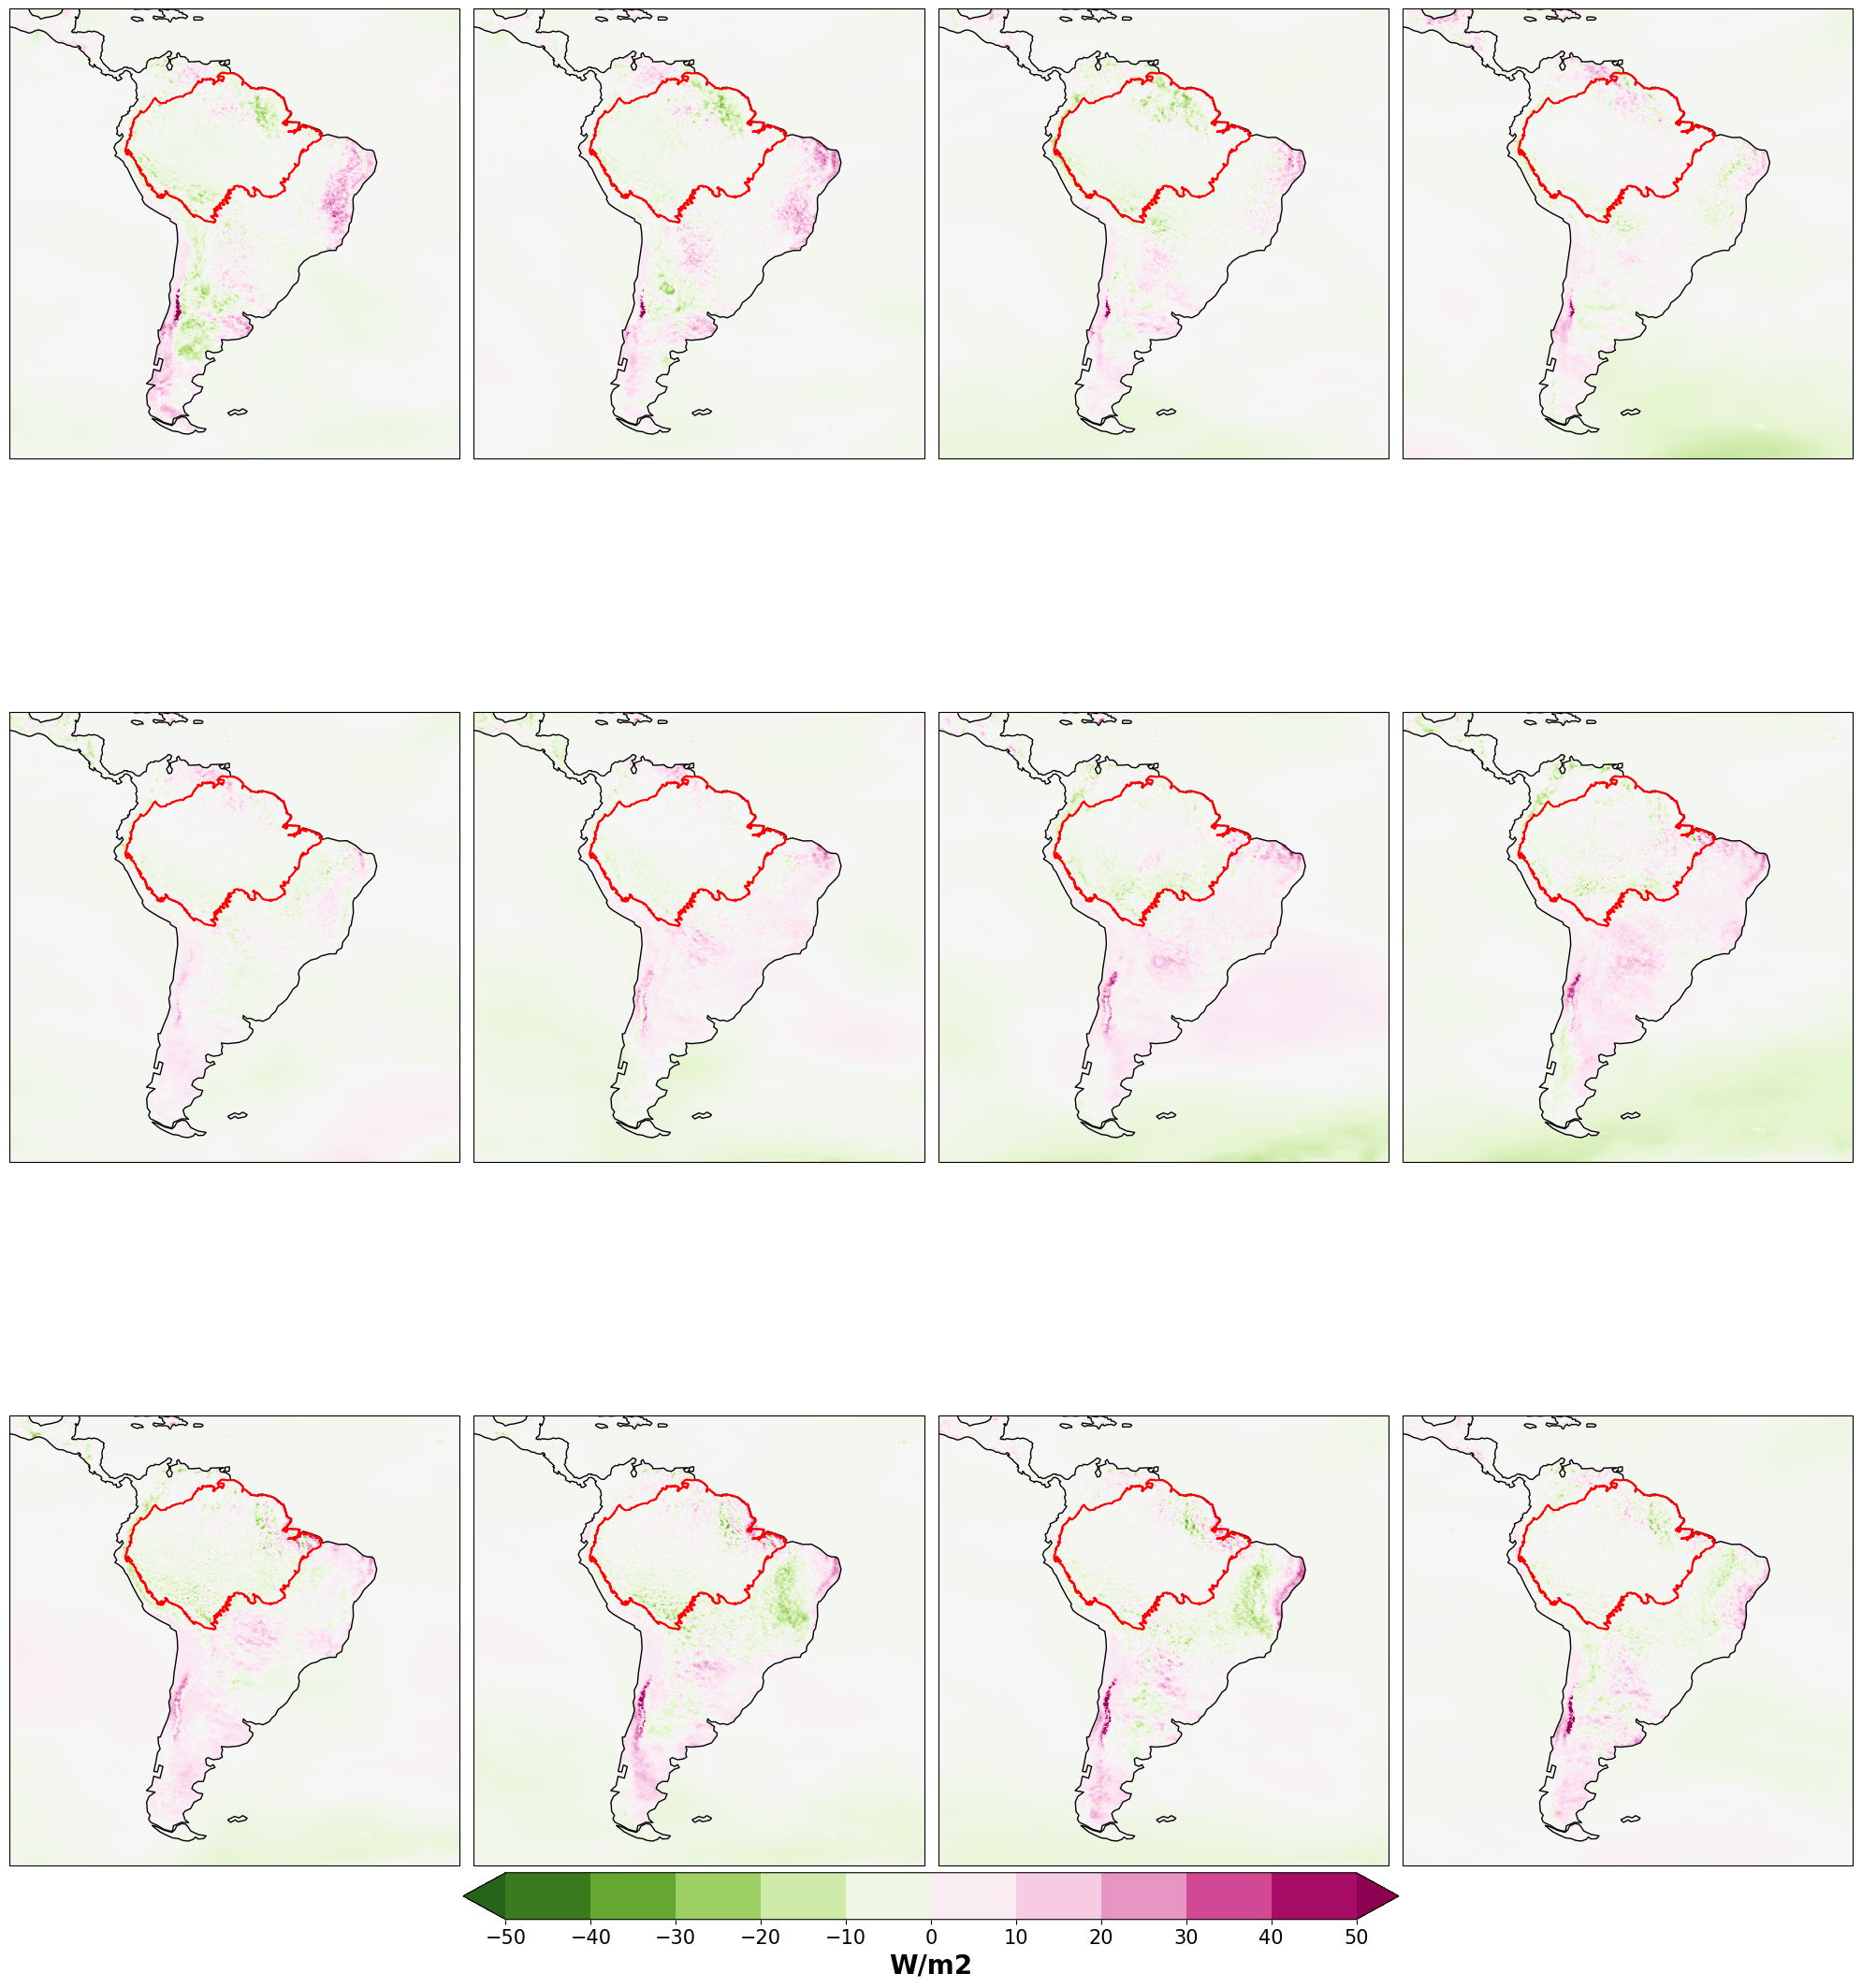

In [41]:
da = hfss_4co2_mon - hfss_ctl_mon
plot_monthly_maps(da, cmap='PiYG_r', nest=True, vmin=-50, vmax=50, space=11, extend='both', label='W/m2',
                      latmin=-60, latmax=20, lonmin=-100, lonmax=-20)

## Air column

### AMIP

In [22]:
# rsdt
rsdt_ctl_amz_mon = dx_ctl_amz.rsdt.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rsdt_p4k_amz_mon = dx_p4k_amz.rsdt.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rsdt_4co2_amz_mon = dx_4co2_amz.rsdt.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [23]:
# rsut
rsut_ctl_amz_mon = dx_ctl_amz.rsut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rsut_p4k_amz_mon = dx_p4k_amz.rsut.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rsut_4co2_amz_mon = dx_4co2_amz.rsut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [24]:
# rlut
rlut_ctl_amz_mon = dx_ctl_amz.rlut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 
rlut_p4k_amz_mon = dx_p4k_amz.rlut.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') 
rlut_4co2_amz_mon = dx_4co2_amz.rlut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') 

In [25]:
print(rsdt_ctl_amz_mon.mean(dim=('cell','month')).values)
print(rsdt_4co2_amz_mon.mean(dim=('cell','month')).values)
print(rsdt_p4k_amz_mon.mean(dim=('cell','month')).values)

print(rsut_ctl_amz_mon.mean(dim=('cell','month')).values)
print(rsut_4co2_amz_mon.mean(dim=('cell','month')).values) 
print(rsut_p4k_amz_mon.mean(dim=('cell','month')).values)

print(rlut_ctl_amz_mon.mean(dim=('cell','month')).values)
print(rlut_4co2_amz_mon.mean(dim=('cell','month')).values)
print(rlut_p4k_amz_mon.mean(dim=('cell','month')).values)

412.98096
412.98096
412.99884
116.77736
117.041435
105.94582
241.23674
230.66635
257.1656


_air column_

In [34]:
air_Rd_ctl_amz_mon = rsdt_ctl_amz_mon - rsut_ctl_amz_mon - rlut_ctl_amz_mon - rsds_ctl_amz_mon + rsus_ctl_amz_mon - rlds_ctl_amz_mon + rlus_ctl_amz_mon
air_Rd_p4k_amz_mon = rsdt_p4k_amz_mon - rsut_p4k_amz_mon - rlut_p4k_amz_mon - rsds_p4k_amz_mon + rsus_p4k_amz_mon - rlds_p4k_amz_mon + rlus_p4k_amz_mon
air_Rd_4co2_amz_mon = rsdt_4co2_amz_mon - rsut_4co2_amz_mon - rlut_4co2_amz_mon - rsds_4co2_amz_mon + rsus_4co2_amz_mon - rlds_4co2_amz_mon + rlus_4co2_amz_mon

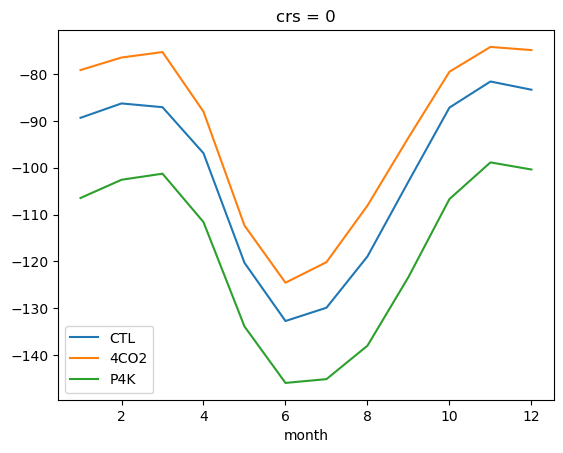

In [35]:
air_Rd_ctl_amz_mon.mean('cell').plot()
air_Rd_4co2_amz_mon.mean('cell').plot()
air_Rd_p4k_amz_mon.mean('cell').plot()
plt.legend(['CTL', '4CO2', 'P4K'])

In [36]:
print(air_Rd_ctl_amz_mon.mean('cell').values)
print(air_Rd_4co2_amz_mon.mean('cell').values) 
print(air_Rd_p4k_amz_mon.mean('cell').values)

[ -89.351845  -86.28371   -87.083336  -96.90937  -120.30359  -132.72948
 -129.8948   -118.94493  -102.96098   -87.16677   -81.60059   -83.35303 ]
[ -79.154366  -76.48159   -75.31336   -88.03081  -112.34546  -124.55229
 -120.16776  -108.09164   -93.57575   -79.521454  -74.21867   -74.8916  ]
[-106.47029  -102.574615 -101.281654 -111.61004  -133.89116  -145.94725
 -145.13817  -138.00209  -123.34702  -106.70005   -98.86937  -100.38708 ]


In [37]:
print(np.sum(np.array([ -89.351845,  -86.28371,   -87.083336,  -96.90937, -120.30359,  -132.72948,
 -129.8948,   -118.94493,  -102.96098,   -87.16677,   -81.60059,   -83.35303 ])/12))
print(np.sum([ -79.154366,  -76.48159,   -75.31336,   -88.03081,  -112.34546,  -124.55229,
 -120.16776,  -108.09164,   -93.57575,   -79.521454,  -74.21867,   -74.8916  ])/12)
print(np.sum([-106.47029,  -102.574615, -101.281654, -111.61004,  -133.89116,  -145.94725,
 -145.13817,  -138.00209,  -123.34702,  -106.70005,   -98.86937 , -100.38708 ])/12)

-101.38186925
-92.19539583333334
-117.85156575


### icon

In [26]:
rsdt_ngc_start_amz_month = dx_ngc_start_amz.rsdt.groupby('time.month').mean('time') 
rsdt_ngc_end_amz_month = dx_ngc_end_amz.rsdt.groupby('time.month').mean('time') 

rsut_ngc_start_amz_month = dx_ngc_start_amz.rsut.groupby('time.month').mean('time') 
rsut_ngc_end_amz_month = dx_ngc_end_amz.rsut.groupby('time.month').mean('time') 

rlut_ngc_start_amz_month = dx_ngc_start_amz.rlut.groupby('time.month').mean('time') 
rlut_ngc_end_amz_month = dx_ngc_end_amz.rlut.groupby('time.month').mean('time') 

In [27]:
print(rsdt_ngc_start_amz_month.mean(dim=('cell','month')).values)
print(rsdt_ngc_end_amz_month.mean(dim=('cell','month')).values)

print(rsut_ngc_start_amz_month.mean(dim=('cell','month')).values)
print(rsut_ngc_end_amz_month.mean(dim=('cell','month')).values)

print(rlut_ngc_start_amz_month.mean(dim=('cell','month')).values)
print(rlut_ngc_end_amz_month.mean(dim=('cell','month')).values)

413.0037
413.02283
104.135345
100.435455
251.45651
253.09555


In [22]:
air_Rd_ngc_start_amz_mon = rsdt_ngc_start_amz_month - rsut_ngc_start_amz_month - rlut_ngc_start_amz_month - rsds_ngc_start_amz_month + rsus_ngc_start_amz_month - rlds_ngc_start_amz_month + rlus_ngc_start_amz_month
air_Rd_ngc_end_amz_mon = rsdt_ngc_end_amz_month - rsut_ngc_end_amz_month - rlut_ngc_end_amz_month - rsds_ngc_end_amz_month + rsus_ngc_end_amz_month - rlds_ngc_end_amz_month + rlus_ngc_end_amz_month

In [24]:
TOTAL_Energy_begin = air_Rd_ngc_start_amz_mon + sfc_Rd_ngc_start_amz_mon
TOTAL_Energy_end = air_Rd_ngc_end_amz_mon + sfc_Rd_ngc_end_amz_mon

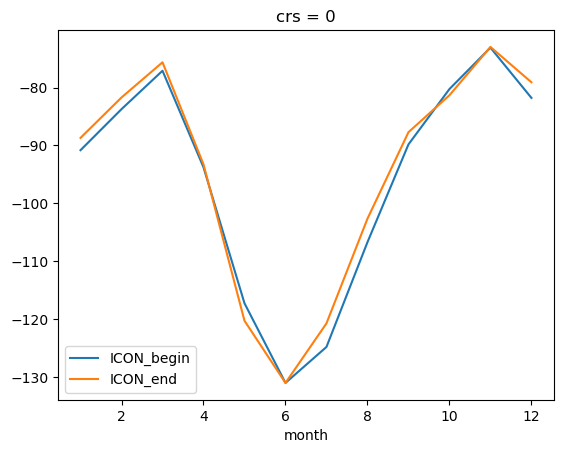

In [23]:
air_Rd_ngc_start_amz_mon.mean('cell').plot()
air_Rd_ngc_end_amz_mon.mean('cell').plot()
plt.legend(['ICON_begin', 'ICON_end'])

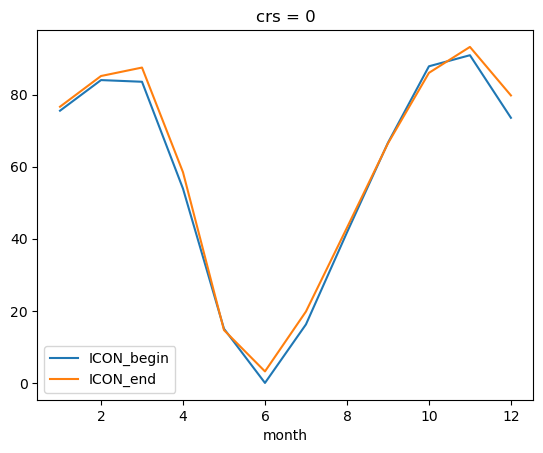

In [25]:
TOTAL_Energy_begin.mean('cell').plot()
TOTAL_Energy_end.mean('cell').plot()
plt.legend(['ICON_begin', 'ICON_end'])

In [26]:
print(air_Rd_ngc_start_amz_mon.mean(dim=('cell','month')).values)
print(air_Rd_ngc_end_amz_mon.mean(dim=('cell','month')).values)
print(sfc_Rd_ngc_start_amz_mon.mean(dim=('cell','month')).values)
print(sfc_Rd_ngc_end_amz_mon.mean(dim=('cell','month')).values)

-95.85609
-94.598885
153.26797
154.09077


## Precip and Evap

In [44]:
# pr
pr_ctl_amz_mon = dx_ctl_amz.pr.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') *86400
pr_p4k_amz_mon = dx_p4k_amz.pr.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') *86400
pr_4co2_amz_mon = dx_4co2_amz.pr.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') *86400

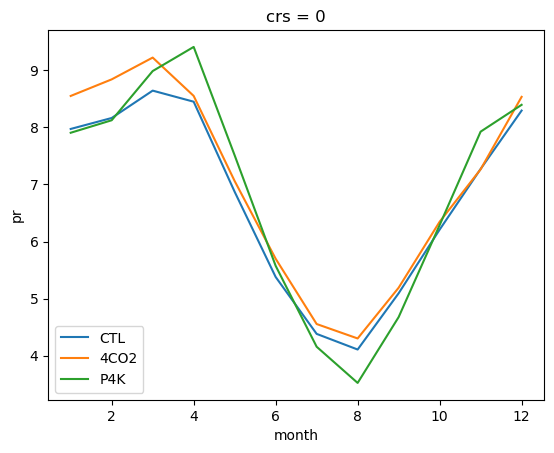

In [45]:
pr_ctl_amz_mon.mean('cell').plot()
pr_4co2_amz_mon.mean('cell').plot()
pr_p4k_amz_mon.mean('cell').plot()
plt.legend(['CTL', '4CO2', 'P4K'])

In [39]:
# hfls
hfls_ctl_amz_mon = -dx_ctl_amz.hfls.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') /28.94
hfls_p4k_amz_mon = -dx_p4k_amz.hfls.sel(time=slice("1979", "1993")).groupby('time.month').mean('time') /28.94
hfls_4co2_amz_mon = -dx_4co2_amz.hfls.sel(time=slice("1980", "1994")).groupby('time.month').mean('time') /28.94

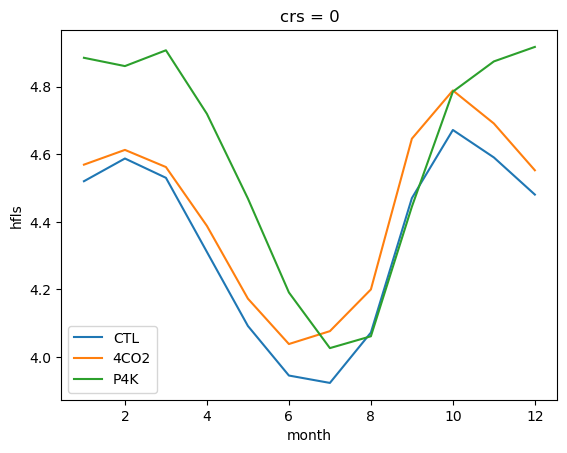

In [46]:
hfls_ctl_amz_mon.mean('cell').plot()
hfls_4co2_amz_mon.mean('cell').plot()
hfls_p4k_amz_mon.mean('cell').plot()
plt.legend(['CTL', '4CO2', 'P4K'])

In [40]:
print(pr_ctl_amz_mon.mean('cell').values*86400)
print(pr_4co2_amz_mon.mean('cell').values*86400) 
print(pr_p4k_amz_mon.mean('cell').values*86400)

[7.97159853 8.16354328 8.64281422 8.44883644 6.87057478 5.37892312
 4.3823009  4.10833588 5.09335619 6.20813998 7.27083539 8.29343344]
[8.54964873 8.84008231 9.22163827 8.55027423 7.05890169 5.6984484
 4.55501358 4.30223445 5.19057799 6.34570022 7.26428053 8.53367555]
[7.90490017 8.12397713 8.98557287 9.40831499 7.50910104 5.57417516
 4.15707267 3.52338916 4.6760075  6.28718678 7.92417813 8.39429288]


In [41]:
print(hfls_ctl_amz_mon.mean('cell').values)
print(hfls_4co2_amz_mon.mean('cell').values) 
print(hfls_p4k_amz_mon.mean('cell').values)

[4.520091  4.5872664 4.5301614 4.310937  4.09208   3.9455647 3.923722
 4.0726404 4.470123  4.6716094 4.5903993 4.480602 ]
[4.5690665 4.6127024 4.5620027 4.3879504 4.1728945 4.0387115 4.076804
 4.200099  4.645879  4.788476  4.6907787 4.552458 ]
[4.885001  4.860505  4.9072423 4.7192774 4.468823  4.191173  4.0266495
 4.0616517 4.444827  4.784922  4.874309  4.9171743]


In [42]:
print(np.sum([7.97159853, 8.16354328, 8.64281422, 8.44883644, 6.87057478, 5.37892312,
 4.3823009,  4.10833588, 5.09335619, 6.20813998, 7.27083539, 8.29343344])/12)
print(np.sum([8.54964873, 8.84008231, 9.22163827, 8.55027423, 7.05890169, 5.6984484,
 4.55501358, 4.30223445, 5.19057799, 6.34570022, 7.26428053, 8.53367555])/12)
print(np.sum([7.90490017, 8.12397713, 8.98557287, 9.40831499, 7.50910104, 5.57417516,
 4.15707267, 3.52338916, 4.6760075,  6.28718678, 7.92417813, 8.39429288])/12)

6.736057679166667
7.009206329166666
6.872347373333333


In [43]:
print(np.sum([4.520091 , 4.5872664 ,4.5301614 ,4.310937 , 4.09208 ,3.9455647 ,3.923722,
 4.0726404, 4.470123,  4.6716094, 4.5903993, 4.480602 ])/12)
print(np.sum([4.5690665 ,4.6127024, 4.5620027, 4.3879504, 4.1728945, 4.0387115, 4.076804,
 4.200099 , 4.645879 , 4.788476,  4.6907787, 4.552458 ])/12)
print(np.sum([4.885001 , 4.860505,  4.9072423, 4.7192774, 4.468823,  4.191173,  4.0266495,
 4.0616517, 4.444827,  4.784922,  4.874309,  4.9171743])/12)

4.349599716666667
4.441485225000001
4.5951296


In [47]:
## Gamma
ctl_gamma = (156.34-101.38)/(6.74-4.35)
co2_gamma = (157.46-92.20)/(7.01-4.44)
p4k_gamma = (167.74-117.85)/(6.87-4.60)


In [48]:
print(ctl_gamma, co2_gamma, p4k_gamma)

22.995815899581586 25.392996108949426 21.97797356828194


# 2. Over the Ocean

### Land and Ocean separation

In [17]:
def land(ds):
    land_mask = data_ctl.cell_sea_land_mask.compute()
    return ds.where(land_mask >= 0, drop=True)

def ocean(ds):
    ocean_mask = data_ctl.cell_sea_land_mask.compute()
    return ds.where(ocean_mask < 0, drop=True)

In [18]:
def land_interest(ds):
    return (ds.lat >= -18) & (ds.lat <= 8) & (ds.lon >= 300) & (ds.lon <= 325)
def ocean_interest(ds):
    return (ds.lat >= -18) & (ds.lat <= 8) & (ds.lon >= 300) & (ds.lon <= 340)

In [19]:
def land_ngc(ds):
    land_mask = dx_ngc.ocean_fraction_surface.compute()
    return ds.where(land_mask <= 0, drop=True)

def ocean_ngc(ds):
    ocean_mask = dx_ngc.ocean_fraction_surface.compute()
    return ds.where(ocean_mask > 0, drop=True)

### 2-1. AMIP

##### Radiations

In [22]:
# SFC and TOA
rsds_ctl = data_ctl.rsds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rsus_ctl = data_ctl.rsus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rlds_ctl = data_ctl.rlds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rlus_ctl = data_ctl.rlus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rsdt_ctl = data_ctl.rsdt.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rsut_ctl = data_ctl.rsut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rlut_ctl = data_ctl.rlut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')

In [43]:
hfls_ctl = data_ctl.hfls.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
hfss_ctl = data_ctl.hfss.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')

In [24]:
# SFC and TOA
rsds_4co2 = dx_4co2.rsds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rsus_4co2 = dx_4co2.rsus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rlds_4co2 = dx_4co2.rlds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rlus_4co2 = dx_4co2.rlus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rsdt_4co2 = dx_4co2.rsdt.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rsut_4co2 = dx_4co2.rsut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rlut_4co2 = dx_4co2.rlut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')

In [44]:
hfls_4co2 = dx_4co2.hfls.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
hfss_4co2 = dx_4co2.hfss.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')

In [25]:
# SFC and TOA
rsds_p4k = dx_p4k.rsds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rsus_p4k = dx_p4k.rsus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rlds_p4k = dx_p4k.rlds.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rlus_p4k = dx_p4k.rlus.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rsdt_p4k = dx_p4k.rsdt.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rsut_p4k = dx_p4k.rsut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
rlut_p4k = dx_p4k.rlut.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')

In [45]:
hfls_p4k = dx_p4k.hfls.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')
hfss_p4k = dx_p4k.hfss.sel(time=slice("1980", "1994")).groupby('time.month').mean('time')

In [29]:
rsds_ctl_ocean = ocean(rsds_ctl)
rsus_ctl_ocean = ocean(rsus_ctl)
rlds_ctl_ocean = ocean(rlds_ctl)
rlus_ctl_ocean = ocean(rlus_ctl)
rsdt_ctl_ocean = ocean(rsdt_ctl)
rsut_ctl_ocean = ocean(rsut_ctl)
rlut_ctl_ocean = ocean(rlut_ctl)

In [46]:
hfls_ctl_ocean = ocean(hfls_ctl)
hfss_ctl_ocean = ocean(hfss_ctl)

In [30]:
rsds_4co2_ocean = ocean(rsds_4co2)
rsus_4co2_ocean = ocean(rsus_4co2)
rlds_4co2_ocean = ocean(rlds_4co2)
rlus_4co2_ocean = ocean(rlus_4co2)
rsdt_4co2_ocean = ocean(rsdt_4co2)
rsut_4co2_ocean = ocean(rsut_4co2)
rlut_4co2_ocean = ocean(rlut_4co2)

In [47]:
hfls_4co2_ocean = ocean(hfls_4co2)
hfss_4co2_ocean = ocean(hfss_4co2)

In [31]:
rsds_p4k_ocean = ocean(rsds_p4k)
rsus_p4k_ocean = ocean(rsus_p4k)
rlds_p4k_ocean = ocean(rlds_p4k)
rlus_p4k_ocean = ocean(rlus_p4k)
rsdt_p4k_ocean = ocean(rsdt_p4k)
rsut_p4k_ocean = ocean(rsut_p4k)
rlut_p4k_ocean = ocean(rlut_p4k)

In [48]:
hfls_p4k_ocean = ocean(hfls_p4k)
hfss_p4k_ocean = ocean(hfss_p4k)

In [32]:
# Ocean interest
rsds_ctl_ocean_interest = rsds_ctl_ocean.where(ocean_interest(rsds_ctl_ocean), drop=True)
rsus_ctl_ocean_interest = rsus_ctl_ocean.where(ocean_interest(rsus_ctl_ocean), drop=True)
rlds_ctl_ocean_interest = rlds_ctl_ocean.where(ocean_interest(rlds_ctl_ocean), drop=True)
rlus_ctl_ocean_interest = rlus_ctl_ocean.where(ocean_interest(rlus_ctl_ocean), drop=True)
rsdt_ctl_ocean_interest = rsdt_ctl_ocean.where(ocean_interest(rsdt_ctl_ocean), drop=True)
rsut_ctl_ocean_interest = rsut_ctl_ocean.where(ocean_interest(rsut_ctl_ocean), drop=True)
rlut_ctl_ocean_interest = rlut_ctl_ocean.where(ocean_interest(rlut_ctl_ocean), drop=True)

In [49]:
hfls_ctl_ocean_interest = hfls_ctl_ocean.where(ocean_interest(hfls_ctl_ocean), drop=True)
hfss_ctl_ocean_interest = hfss_ctl_ocean.where(ocean_interest(hfss_ctl_ocean), drop=True)

In [33]:
# Ocean interest
rsds_4co2_ocean_interest = rsds_4co2_ocean.where(ocean_interest(rsds_4co2_ocean), drop=True)
rsus_4co2_ocean_interest = rsus_4co2_ocean.where(ocean_interest(rsus_4co2_ocean), drop=True)
rlds_4co2_ocean_interest = rlds_4co2_ocean.where(ocean_interest(rlds_4co2_ocean), drop=True)
rlus_4co2_ocean_interest = rlus_4co2_ocean.where(ocean_interest(rlus_4co2_ocean), drop=True)
rsdt_4co2_ocean_interest = rsdt_4co2_ocean.where(ocean_interest(rsdt_4co2_ocean), drop=True)
rsut_4co2_ocean_interest = rsut_4co2_ocean.where(ocean_interest(rsut_4co2_ocean), drop=True)
rlut_4co2_ocean_interest = rlut_4co2_ocean.where(ocean_interest(rlut_4co2_ocean), drop=True)

In [50]:
hfls_4co2_ocean_interest = hfls_4co2_ocean.where(ocean_interest(hfls_4co2_ocean), drop=True)
hfss_4co2_ocean_interest = hfss_4co2_ocean.where(ocean_interest(hfss_4co2_ocean), drop=True)

In [34]:
# Ocean interest
rsds_p4k_ocean_interest = rsds_p4k_ocean.where(ocean_interest(rsds_p4k_ocean), drop=True)
rsus_p4k_ocean_interest = rsus_p4k_ocean.where(ocean_interest(rsus_p4k_ocean), drop=True)
rlds_p4k_ocean_interest = rlds_p4k_ocean.where(ocean_interest(rlds_p4k_ocean), drop=True)
rlus_p4k_ocean_interest = rlus_p4k_ocean.where(ocean_interest(rlus_p4k_ocean), drop=True)
rsdt_p4k_ocean_interest = rsdt_p4k_ocean.where(ocean_interest(rsdt_p4k_ocean), drop=True)
rsut_p4k_ocean_interest = rsut_p4k_ocean.where(ocean_interest(rsut_p4k_ocean), drop=True)
rlut_p4k_ocean_interest = rlut_p4k_ocean.where(ocean_interest(rlut_p4k_ocean), drop=True)

In [51]:
hfls_p4k_ocean_interest = hfls_p4k_ocean.where(ocean_interest(hfls_p4k_ocean), drop=True)
hfss_p4k_ocean_interest = hfss_p4k_ocean.where(ocean_interest(hfss_p4k_ocean), drop=True)

In [36]:
air_Rd_ctl_ocean = rsdt_ctl_ocean_interest - rsut_ctl_ocean_interest - rlut_ctl_ocean_interest - rsds_ctl_ocean_interest + rsus_ctl_ocean_interest - rlds_ctl_ocean_interest + rlus_ctl_ocean_interest
air_Rd_4co2_ocean = rsdt_4co2_ocean_interest - rsut_4co2_ocean_interest - rlut_4co2_ocean_interest - rsds_4co2_ocean_interest + rsus_4co2_ocean_interest - rlds_4co2_ocean_interest + rlus_4co2_ocean_interest
air_Rd_p4k_ocean = rsdt_p4k_ocean_interest - rsut_p4k_ocean_interest - rlut_p4k_ocean_interest - rsds_p4k_ocean_interest + rsus_p4k_ocean_interest - rlds_p4k_ocean_interest + rlus_p4k_ocean_interest

In [40]:
air_Rd_ctl_ocean.mean(dim=('cell', 'month')).values

array(-119.08612, dtype=float32)

In [53]:
print(hfls_ctl_ocean_interest.mean(dim=('cell', 'month')).values, hfss_ctl_ocean_interest.mean(dim=('cell', 'month')).values)

-146.18639 -13.637072


In [41]:
air_Rd_4co2_ocean.mean(dim=('cell', 'month')).values

array(-114.59193, dtype=float32)

In [54]:
print(hfls_4co2_ocean_interest.mean(dim=('cell', 'month')).values, hfss_4co2_ocean_interest.mean(dim=('cell', 'month')).values)

-137.71924 -12.282227


In [42]:
air_Rd_p4k_ocean.mean(dim=('cell', 'month')).values

array(-129.19353, dtype=float32)

In [55]:
print(hfls_p4k_ocean_interest.mean(dim=('cell', 'month')).values, hfss_p4k_ocean_interest.mean(dim=('cell', 'month')).values)

-166.24501 -12.243311


### 2-2. ICON_C

##### Radiations

In [56]:
# SFC and TOA
rsds_ngc_start = dx_ngc_start.rsds.groupby('time.month').mean('time')
rsus_ngc_start = dx_ngc_start.rsus.groupby('time.month').mean('time')
rlds_ngc_start = dx_ngc_start.rlds.groupby('time.month').mean('time')
rlus_ngc_start = dx_ngc_start.rlus.groupby('time.month').mean('time')
rsdt_ngc_start = dx_ngc_start.rsdt.groupby('time.month').mean('time')
rsut_ngc_start = dx_ngc_start.rsut.groupby('time.month').mean('time')
rlut_ngc_start = dx_ngc_start.rlut.groupby('time.month').mean('time')

In [57]:
hfls_ngc_start = dx_ngc_start.hfls.groupby('time.month').mean('time')
hfss_ngc_start = dx_ngc_start.hfss.groupby('time.month').mean('time')

In [61]:
# SFC and TOA
rsds_ngc_end = dx_ngc_end.rsds.groupby('time.month').mean('time')
rsus_ngc_end = dx_ngc_end.rsus.groupby('time.month').mean('time')
rlds_ngc_end = dx_ngc_end.rlds.groupby('time.month').mean('time')
rlus_ngc_end = dx_ngc_end.rlus.groupby('time.month').mean('time')
rsdt_ngc_end = dx_ngc_end.rsdt.groupby('time.month').mean('time')
rsut_ngc_end = dx_ngc_end.rsut.groupby('time.month').mean('time')
rlut_ngc_end = dx_ngc_end.rlut.groupby('time.month').mean('time')

In [62]:
hfls_ngc_end = dx_ngc_end.hfls.groupby('time.month').mean('time')
hfss_ngc_end = dx_ngc_end.hfss.groupby('time.month').mean('time')

_ocean_

In [68]:
rsds_ngc_start_ocean_ngc = ocean_ngc(rsds_ngc_start)
rsus_ngc_start_ocean_ngc = ocean_ngc(rsus_ngc_start)
rlds_ngc_start_ocean_ngc = ocean_ngc(rlds_ngc_start)
rlus_ngc_start_ocean_ngc = ocean_ngc(rlus_ngc_start)
rsdt_ngc_start_ocean_ngc = ocean_ngc(rsdt_ngc_start)
rsut_ngc_start_ocean_ngc = ocean_ngc(rsut_ngc_start)
rlut_ngc_start_ocean_ngc = ocean_ngc(rlut_ngc_start)

In [69]:
hfls_ngc_start_ocean_ngc = ocean_ngc(hfls_ngc_start)
hfss_ngc_start_ocean_ngc = ocean_ngc(hfss_ngc_start)

In [70]:
rsds_ngc_end_ocean_ngc = ocean_ngc(rsds_ngc_end)
rsus_ngc_end_ocean_ngc = ocean_ngc(rsus_ngc_end)
rlds_ngc_end_ocean_ngc = ocean_ngc(rlds_ngc_end)
rlus_ngc_end_ocean_ngc = ocean_ngc(rlus_ngc_end)
rsdt_ngc_end_ocean_ngc = ocean_ngc(rsdt_ngc_end)
rsut_ngc_end_ocean_ngc = ocean_ngc(rsut_ngc_end)
rlut_ngc_end_ocean_ngc = ocean_ngc(rlut_ngc_end)

In [71]:
hfls_ngc_end_ocean_ngc = ocean_ngc(hfls_ngc_end)
hfss_ngc_end_ocean_ngc = ocean_ngc(hfss_ngc_end)

_ocean interest_

In [73]:
# ocean_ngc interest
rsds_ngc_start_ocean_ngc_interest = rsds_ngc_start_ocean_ngc.where(ocean_interest(rsds_ngc_start_ocean_ngc), drop=True)
rsus_ngc_start_ocean_ngc_interest = rsus_ngc_start_ocean_ngc.where(ocean_interest(rsus_ngc_start_ocean_ngc), drop=True)
rlds_ngc_start_ocean_ngc_interest = rlds_ngc_start_ocean_ngc.where(ocean_interest(rlds_ngc_start_ocean_ngc), drop=True)
rlus_ngc_start_ocean_ngc_interest = rlus_ngc_start_ocean_ngc.where(ocean_interest(rlus_ngc_start_ocean_ngc), drop=True)
rsdt_ngc_start_ocean_ngc_interest = rsdt_ngc_start_ocean_ngc.where(ocean_interest(rsdt_ngc_start_ocean_ngc), drop=True)
rsut_ngc_start_ocean_ngc_interest = rsut_ngc_start_ocean_ngc.where(ocean_interest(rsut_ngc_start_ocean_ngc), drop=True)
rlut_ngc_start_ocean_ngc_interest = rlut_ngc_start_ocean_ngc.where(ocean_interest(rlut_ngc_start_ocean_ngc), drop=True)

In [74]:
hfls_ngc_start_ocean_ngc_interest = hfls_ngc_start_ocean_ngc.where(ocean_interest(hfls_ngc_start_ocean_ngc), drop=True)
hfss_ngc_start_ocean_ngc_interest = hfss_ngc_start_ocean_ngc.where(ocean_interest(hfss_ngc_start_ocean_ngc), drop=True)

In [75]:
# Ocean interest
rsds_ngc_end_ocean_ngc_interest = rsds_ngc_end_ocean_ngc.where(ocean_interest(rsds_ngc_end_ocean_ngc), drop=True)
rsus_ngc_end_ocean_ngc_interest = rsus_ngc_end_ocean_ngc.where(ocean_interest(rsus_ngc_end_ocean_ngc), drop=True)
rlds_ngc_end_ocean_ngc_interest = rlds_ngc_end_ocean_ngc.where(ocean_interest(rlds_ngc_end_ocean_ngc), drop=True)
rlus_ngc_end_ocean_ngc_interest = rlus_ngc_end_ocean_ngc.where(ocean_interest(rlus_ngc_end_ocean_ngc), drop=True)
rsdt_ngc_end_ocean_ngc_interest = rsdt_ngc_end_ocean_ngc.where(ocean_interest(rsdt_ngc_end_ocean_ngc), drop=True)
rsut_ngc_end_ocean_ngc_interest = rsut_ngc_end_ocean_ngc.where(ocean_interest(rsut_ngc_end_ocean_ngc), drop=True)
rlut_ngc_end_ocean_ngc_interest = rlut_ngc_end_ocean_ngc.where(ocean_interest(rlut_ngc_end_ocean_ngc), drop=True)

In [76]:
hfls_ngc_end_ocean_ngc_interest = hfls_ngc_end_ocean_ngc.where(ocean_interest(hfls_ngc_end_ocean_ngc), drop=True)
hfss_ngc_end_ocean_ngc_interest = hfss_ngc_end_ocean_ngc.where(ocean_interest(hfss_ngc_end_ocean_ngc), drop=True)

In [77]:
air_Rd_ngc_start_ocean_ngc = rsdt_ngc_start_ocean_ngc_interest - rsut_ngc_start_ocean_ngc_interest - rlut_ngc_start_ocean_ngc_interest - rsds_ngc_start_ocean_ngc_interest + rsus_ngc_start_ocean_ngc_interest - rlds_ngc_start_ocean_ngc_interest + rlus_ngc_start_ocean_ngc_interest
air_Rd_ngc_end_ocean_ngc = rsdt_ngc_end_ocean_ngc_interest - rsut_ngc_end_ocean_ngc_interest - rlut_ngc_end_ocean_ngc_interest - rsds_ngc_end_ocean_ngc_interest + rsus_ngc_end_ocean_ngc_interest - rlds_ngc_end_ocean_ngc_interest + rlus_ngc_end_ocean_ngc_interest

In [79]:
print(air_Rd_ngc_start_ocean_ngc.mean(dim=('cell', 'month')).values, air_Rd_ngc_end_ocean_ngc.mean(dim=('cell', 'month')).values)

-112.6947 -114.519554


In [80]:
print(hfls_ngc_start_ocean_ngc_interest.mean(dim=('cell', 'month')).values, hfss_ngc_start_ocean_ngc_interest.mean(dim=('cell', 'month')).values)
print(hfls_ngc_end_ocean_ngc_interest.mean(dim=('cell', 'month')).values, hfss_ngc_end_ocean_ngc_interest.mean(dim=('cell', 'month')).values)

-129.80774 -11.929678
-129.06427 -11.580429


# Plotting

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# Data
#cases = ["4CO2","P4K","Coupled"]
# rsdt, UST, DSS, USS
UST = np.array([117.04-116.78, 105.94-116.78, 100.43-104.14])
DSS = np.array([233.12-234.93, 241.06-234.93, 250.51-246.50])
USS = np.array([34-34.27, 35.13-34.27, 36.52-35.94])
# ULT, DLS, ULS
ULT = np.array([230.67-241.24, 257.17-241.24, 253.10-251.46]) 
DLS = np.array([399.54-394.38, 429.33-394.38, 393.86-389.69])
ULS = np.array([441.20-438.69, 467.52-438.69, 453.76-446.99])
# SH, LH
SH = np.array([28.63-30.23,34.40-30.23, 54.64-48.56]) # hfls, hfss 
LH = np.array([128.54-125.87, 132.98-125.87, 99.37-104.59])


data = {'4CO2': {'UST': UST[0], 'DSS': DSS[0], 'USS':USS[0], 'ULT':ULT[0],'DLS':DLS[0], 'ULS':ULS[0], 'SH':SH[0], 'LH':LH[0]},
        'P4K': {'UST': UST[1], 'DSS': DSS[1], 'USS':USS[1], 'ULT':ULT[1],'DLS':DLS[1], 'ULS':ULS[1], 'SH':SH[1], 'LH':LH[1]},
        'Coupled': {'UST':UST[2], 'DSS':DSS[2], 'USS':USS[2], 'ULT':ULT[2], 'DLS':DLS[2], 'ULS':ULS[2], 'SH':SH[2], 'LH':LH[2]},
        } 
data2 = {'4CO2': {'net SW':96.82-95.54, 'net LW': -189.01+196.93, 'SH+LH':157.17-156 },
        'P4K': {'net SW': 101.11-95.54, 'net LW': -218.98+196.93, 'SH+LH': 167.38-156.1},
        'Coupled': {'net SW': 98.58-98.3, 'net LW': -193.2+194.33, 'SH+LH': 154.01-153.15}}
# data1
df = pd.DataFrame(data)
df = df.T
df['sum']=df.sum(axis=0)
# data2
df2 = pd.DataFrame(data2)
df2 = df2.T
df2['sum']=df2.sum(axis=0)

colors = [
    '#E9C46A',
    '#F4A261',
    '#E76F51',
    '#BDE0FE',
    '#669BBC',
    '#003049',
    '#9C6644',
    '#52B788'
]


fig, ax = plt.subplots(figsize=(12, 6))
df.sort_values('sum', ascending=False)[['UST','DSS','USS','ULT','DLS','ULS','SH','LH']].plot.bar(
    ax=ax,
    color=colors)

# Labels and formatting
ax.tick_params(axis='x', labelsize=20, rotation=0)
ax.tick_params(axis='y', labelsize=20)  # hide tick lines
ax.set_ylabel("W/m²", fontsize=25)
#ax.set_title("Radiative & Heat Flux Changes Across Experiments", fontsize=15)
ax.legend(fontsize=18,ncol=3,handleheight=1.0, labelspacing=0.05, frameon=False)

# Add horizontal line at zero
ax.axhline(0, color='black', linewidth=0.7)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()